# 因子分析 — alphalens

使用 `pct_chg`（当日涨跌幅）作为因子，通过 alphalens 分析其对未来 1/5/10 日收益的预测能力。

数据来源：zer0share 本地 Parquet

In [1]:
import sys
from pathlib import Path

import pandas as pd
import alphalens
from zer0share.api import LocalPro

# zer0share 数据目录（相对 notebook 位置）
DATA_DIR = Path('../..') / 'zer0share' / 'data'
pro = LocalPro(DATA_DIR)

START = '20160101'
END   = '20260401'

print(f'数据目录: {DATA_DIR.resolve()}')

数据目录: D:\Project\zer0share\data


## 1. 加载日线数据

In [2]:
# 加载全市场日线（前复权收盘价 + pct_chg）
daily = pro.daily(start_date=START, end_date=END)
print(f'行数: {len(daily):,}  股票数: {daily["ts_code"].nunique():,}')
daily.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

行数: 10,532,931  股票数: 5,733


,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,000001.SZ,20160104,12.00,12.03,11.23,11.33,11.99,-0.66,-5.50,563497.87,660376.1531
1,000001.SZ,20160105,11.27,11.57,11.15,11.40,11.33,0.07,0.62,663269.95,755531.3537
2,000001.SZ,20160106,11.42,11.56,11.39,11.53,11.40,0.13,1.14,515706.44,591698.5204
3,000001.SZ,20160107,11.41,11.41,10.91,10.94,11.53,-0.59,-5.12,174761.10,194869.4935
4,000001.SZ,20160108,11.21,11.29,10.90,11.12,10.94,0.18,1.65,747527.58,831334.5462


## 2. 构建因子与价格矩阵

In [3]:
# trade_date → datetime index
daily['date'] = pd.to_datetime(daily['trade_date'], format='%Y%m%d')

# 过滤：剔除当日无涨跌幅或成交量为 0 的行
daily = daily[(daily['pct_chg'].notna()) & (daily['vol'] > 0)]

# 价格矩阵：行=日期，列=ts_code（用前复权收盘价）
prices = daily.pivot(index='date', columns='ts_code', values='close')

# 因子：pct_chg，MultiIndex (date, asset)
factor = (
    daily
    .set_index(['date', 'ts_code'])['pct_chg']
    .rename_axis(['date', 'asset'])
)

print(f'价格矩阵: {prices.shape}  因子长度: {len(factor):,}')

价格矩阵: (2487, 5733)  因子长度: 10,532,763


In [9]:
factor.head()

date        asset    
2016-01-04  000001.SZ   -5.50
2016-01-05  000001.SZ    0.62
2016-01-06  000001.SZ    1.14
2016-01-07  000001.SZ   -5.12
2016-01-08  000001.SZ    1.65
Name: pct_chg, dtype: float64

## 3. alphalens 因子清洗

In [5]:
factor_data = alphalens.utils.get_clean_factor_and_forward_returns(
    factor,
    prices,
    quantiles=5,
    periods=(1, 5, 10),
    max_loss=0.35,
)
print(f'清洗后样本: {len(factor_data):,}')
factor_data.head()

d:\Project\zer0factor\.venv\Lib\site-packages\alphalens\utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
d:\Project\zer0factor\.venv\Lib\site-packages\alphalens\utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
d:\Project\zer0factor\.venv\Lib\site-packages\alphalens\utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None'

Dropped 0.5% entries from factor data: 0.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
清洗后样本: 10,477,783


,,1D,5D,10D,factor,factor_quantile
date,asset,,,,,
2016-01-04,000001.SZ,0.006178,-0.050309,-0.081200,-5.50,5
2016-01-05,000001.SZ,0.011404,-0.051754,-0.060526,0.62,4
2016-01-06,000001.SZ,-0.051171,-0.071119,-0.085863,1.14,1
2016-01-07,000001.SZ,0.016453,-0.015539,-0.056673,-5.12,5
2016-01-08,000001.SZ,-0.032374,-0.059353,-0.064748,1.65,3


## 4. IC 分析

Information Analysis


,1D,5D,10D
IC Mean,-0.017,-0.011,-0.005
IC Std.,0.137,0.126,0.117
Risk-Adjusted IC,-0.125,-0.088,-0.046
t-stat(IC),-6.209,-4.368,-2.292
p-value(IC),0.000,0.000,0.022
IC Skew,0.509,-0.067,-0.184
IC Kurtosis,2.130,1.627,1.965


d:\Project\zer0factor\.venv\Lib\site-packages\alphalens\performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


<Figure size 640x480 with 0 Axes>

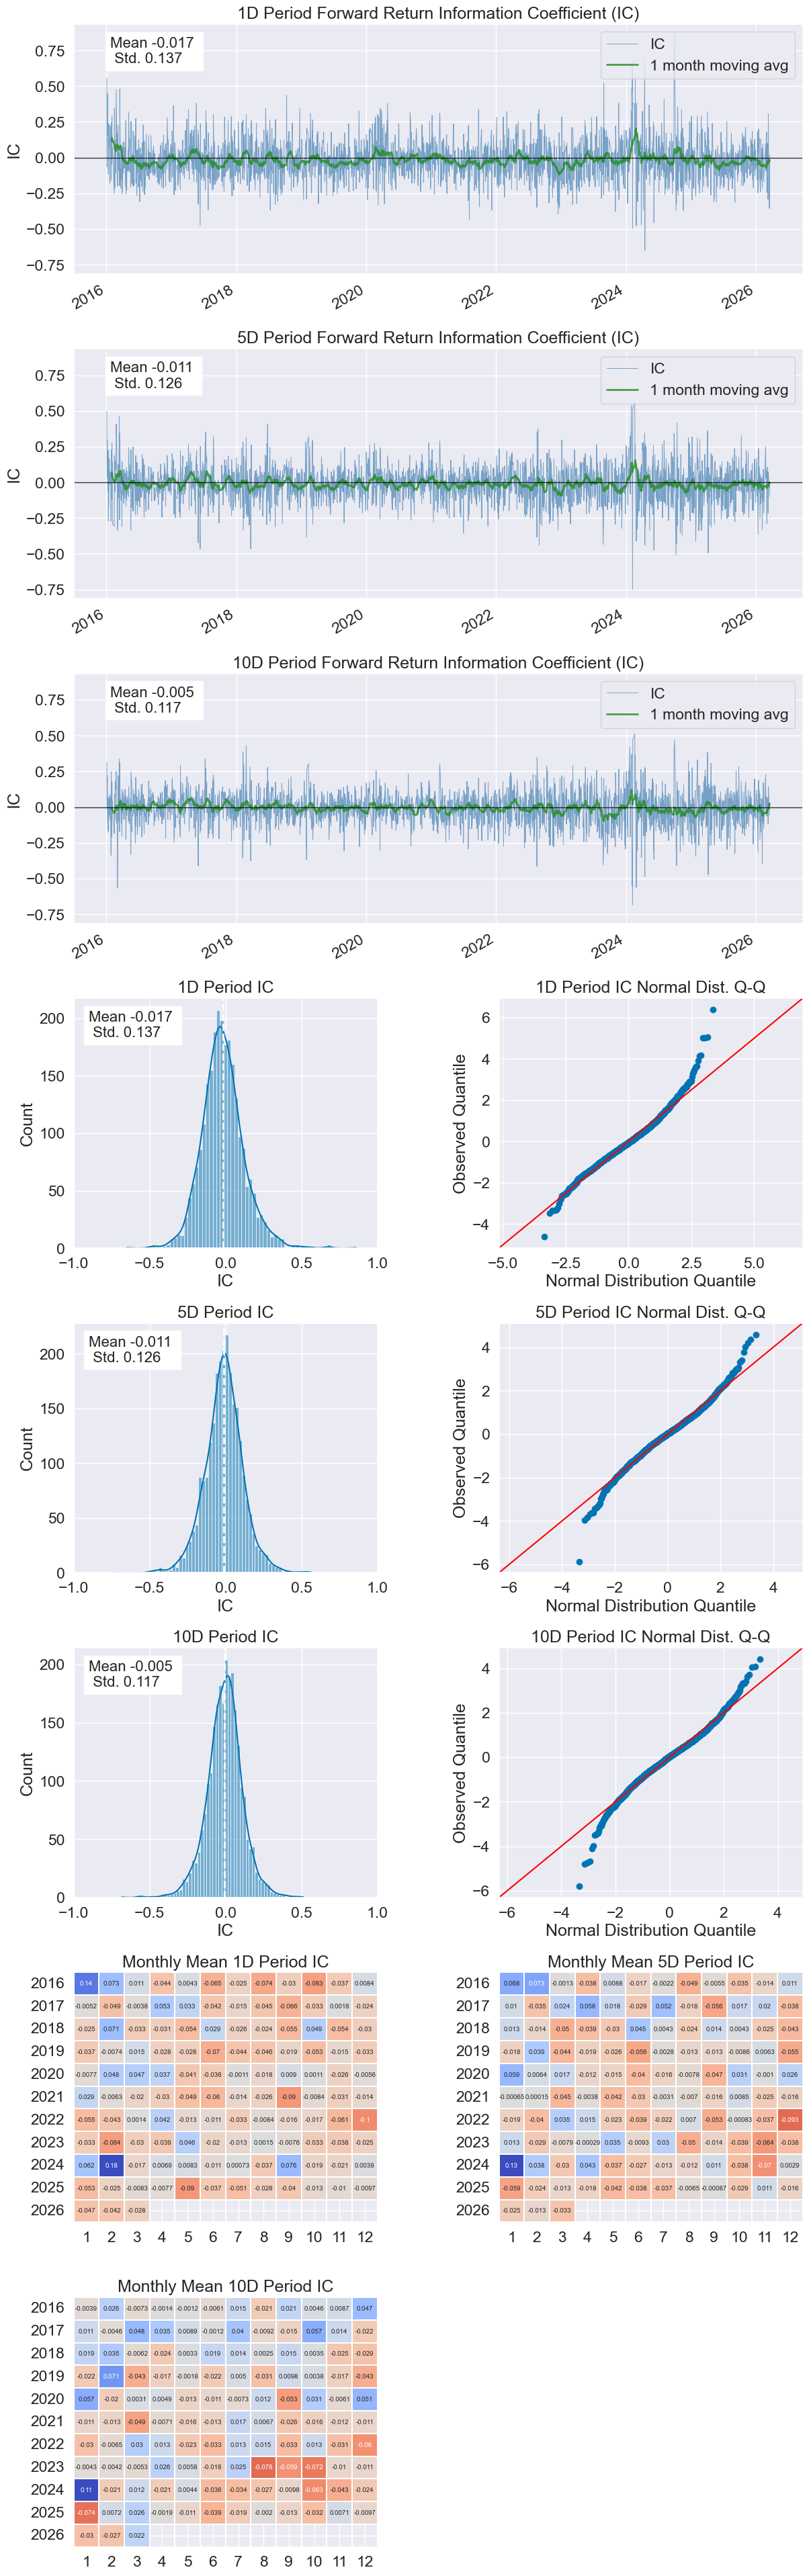

In [6]:
alphalens.tears.create_information_tear_sheet(factor_data)

## 5. 分组收益分析

Returns Analysis


,1D,5D,10D
Ann. alpha,0.547,0.255,0.252
beta,-0.063,-0.051,-0.066
Mean Period Wise Return Top Quantile (bps),7.946,0.962,0.938
Mean Period Wise Return Bottom Quantile (bps),-11.565,-4.497,-3.729
Mean Period Wise Spread (bps),19.511,5.439,4.644


<Figure size 640x480 with 0 Axes>

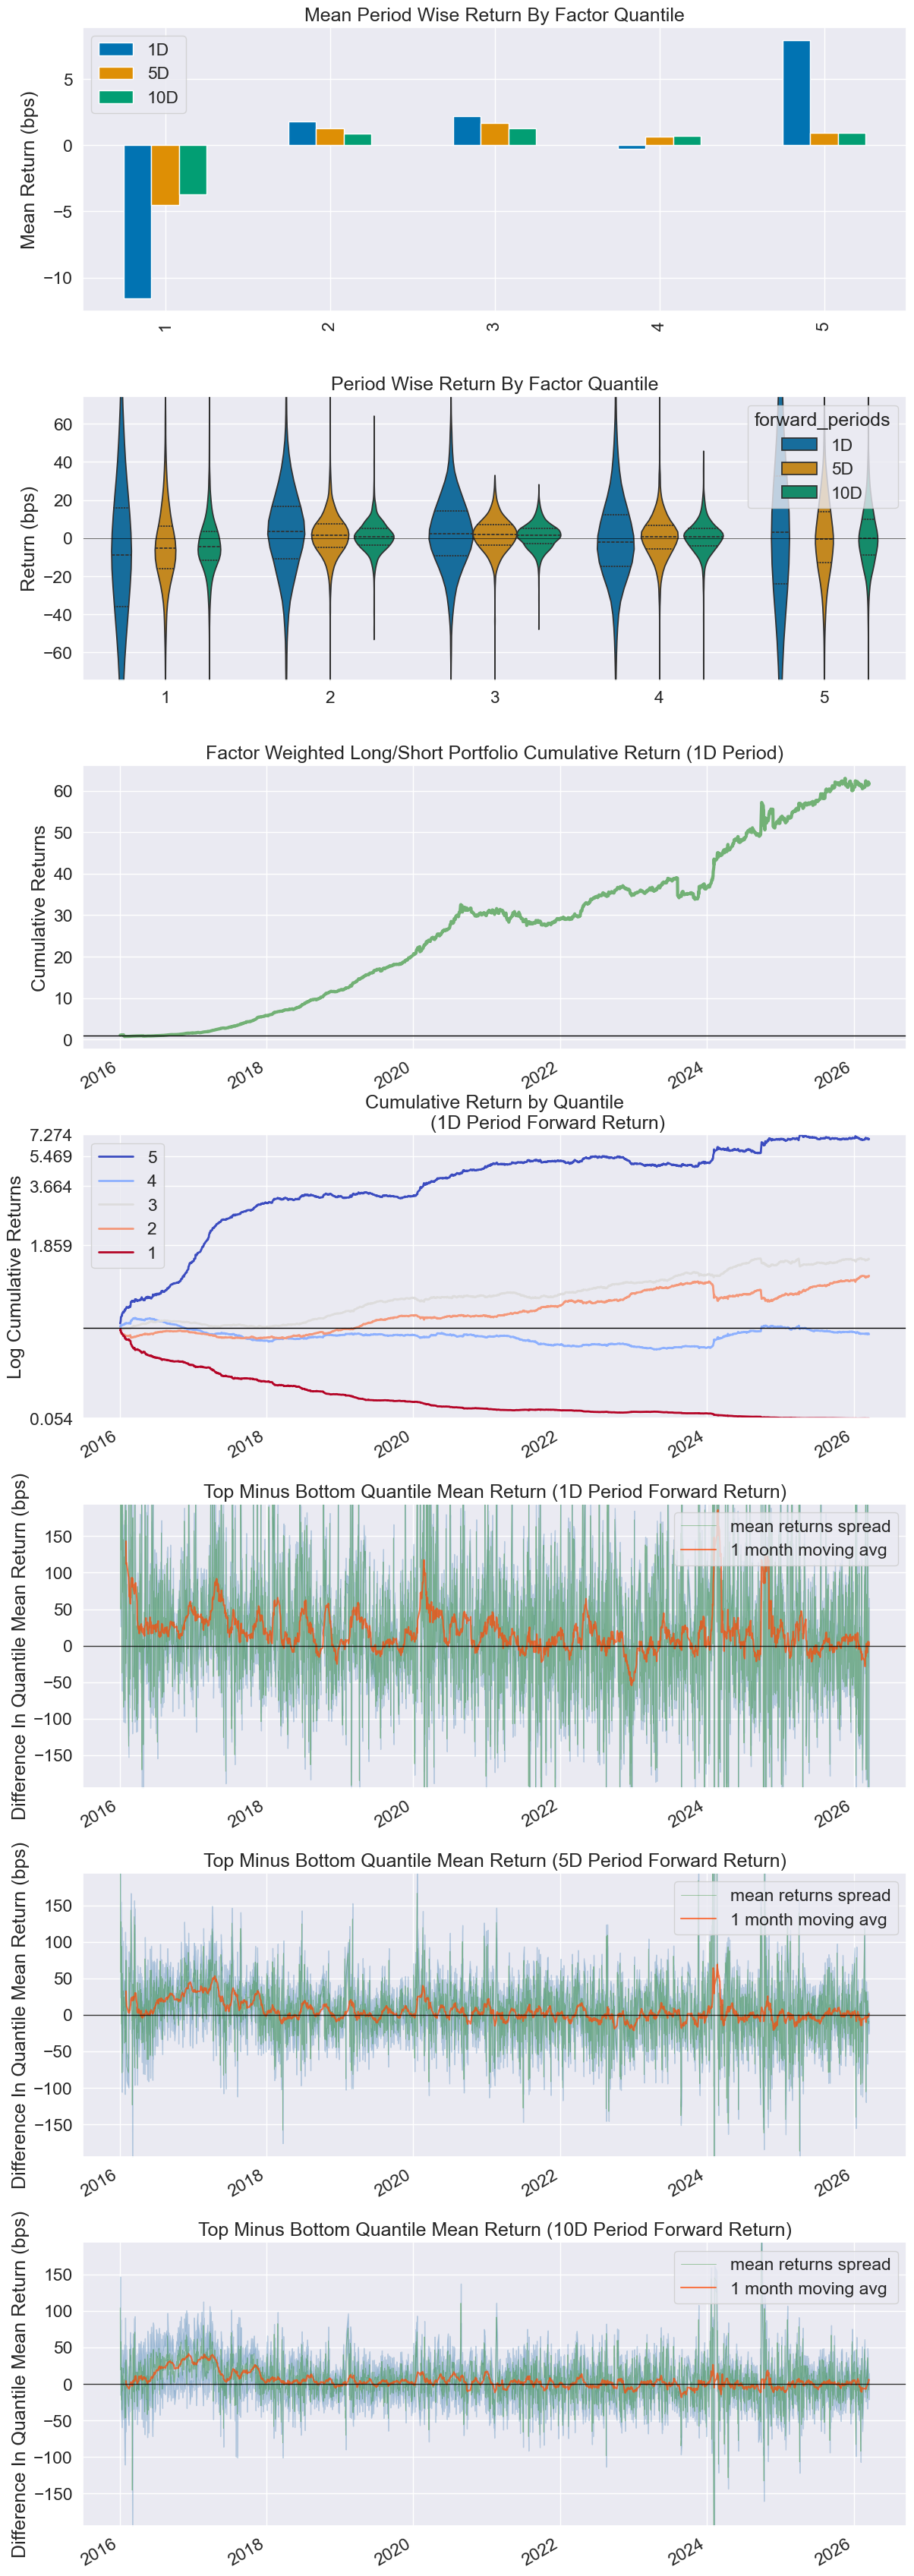

In [7]:
alphalens.tears.create_returns_tear_sheet(factor_data)

## 6. 完整报告

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-96.4431,8.0000,-2.949187,2.661560,2102107,20.062517
2,-18.7608,9.3366,-0.994094,1.610636,2105124,20.091311
3,-10.0551,10.9730,-0.174479,1.510241,2093808,19.983311
4,-9.9997,15.3584,0.731776,1.526667,2084110,19.890754
5,-9.8765,200400.0000,3.995991,165.220489,2092634,19.972107


Returns Analysis


,1D,5D,10D
Ann. alpha,0.547,0.255,0.252
beta,-0.063,-0.051,-0.066
Mean Period Wise Return Top Quantile (bps),7.946,0.962,0.938
Mean Period Wise Return Bottom Quantile (bps),-11.565,-4.497,-3.729
Mean Period Wise Spread (bps),19.511,5.439,4.644


<Figure size 640x480 with 0 Axes>

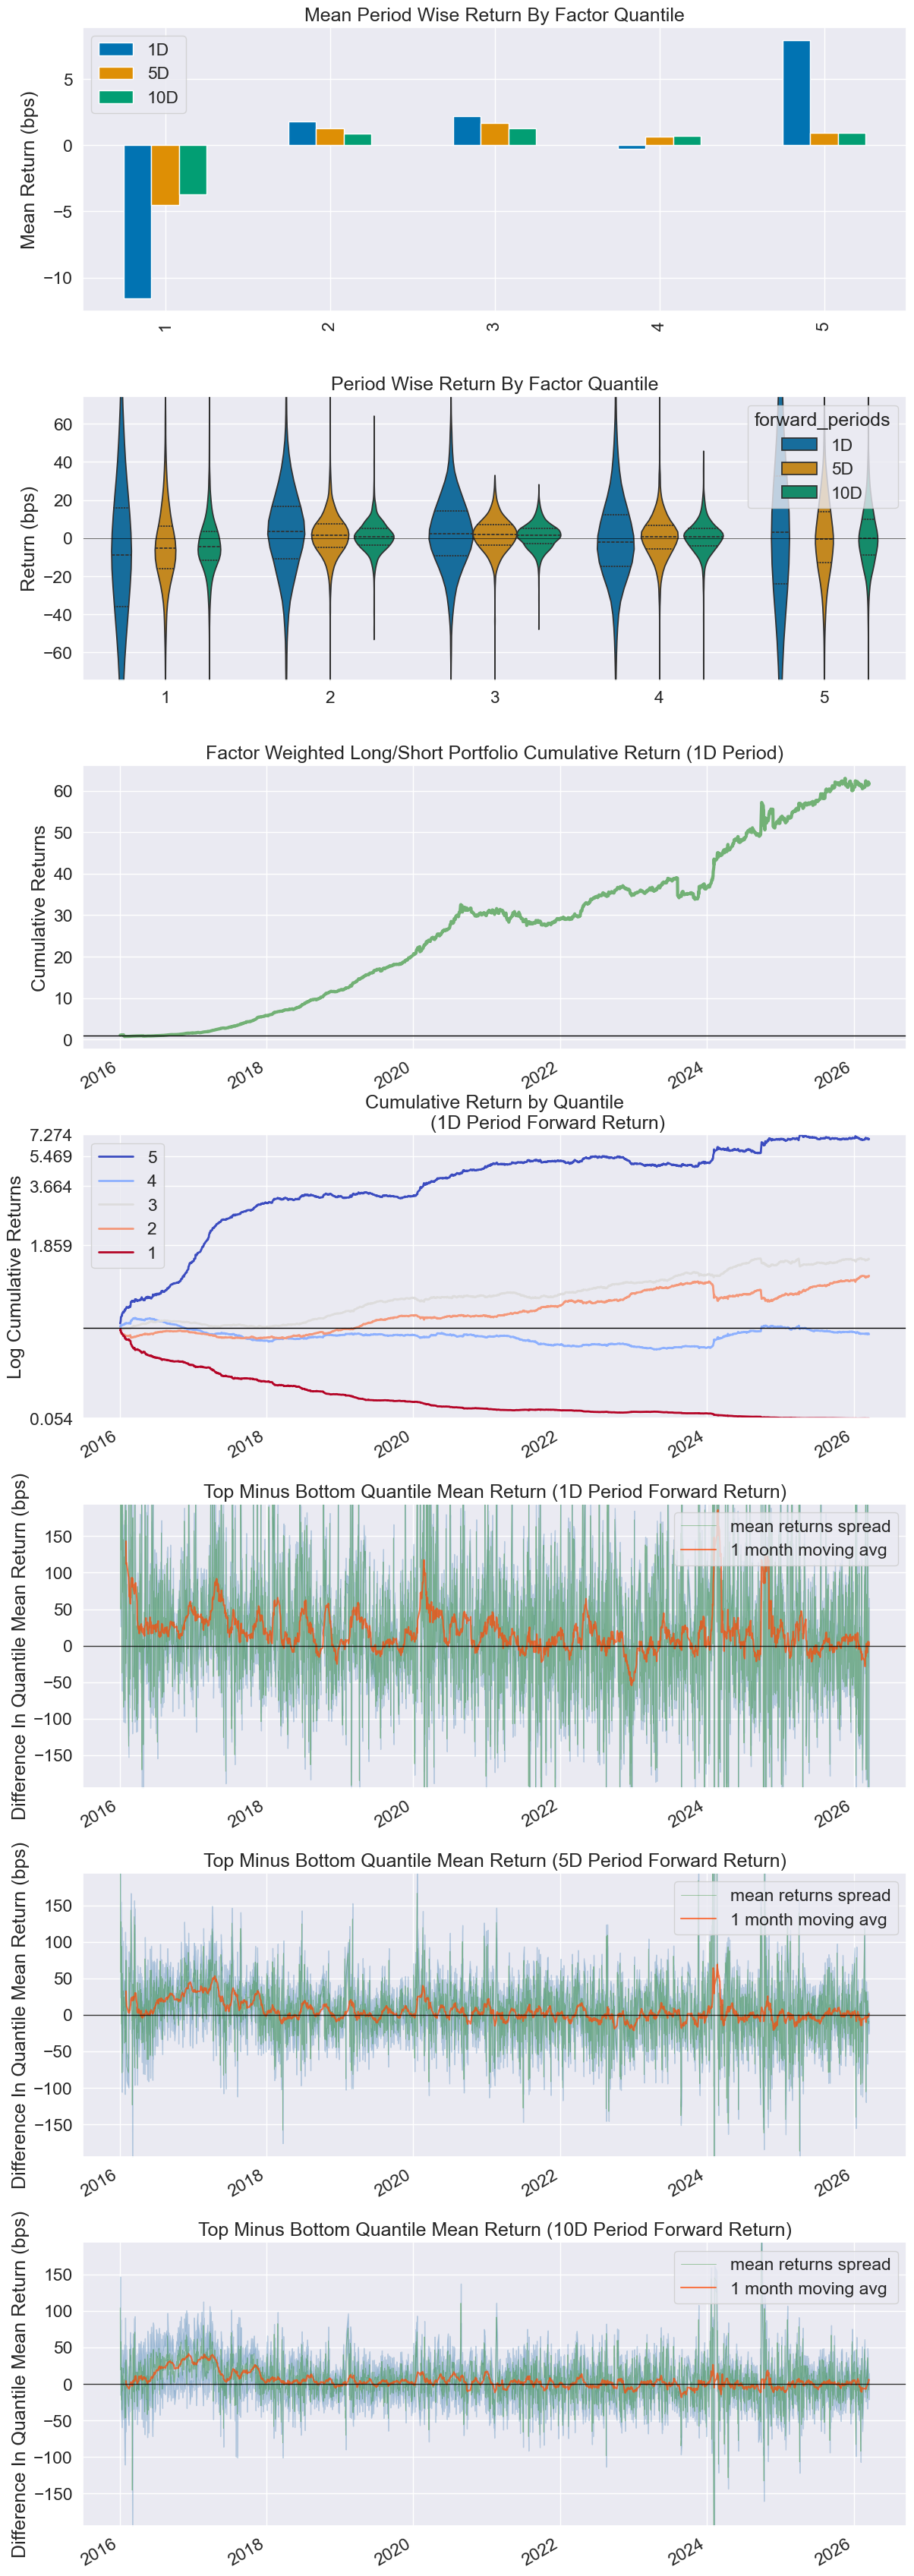

Information Analysis


,1D,5D,10D
IC Mean,-0.017,-0.011,-0.005
IC Std.,0.137,0.126,0.117
Risk-Adjusted IC,-0.125,-0.088,-0.046
t-stat(IC),-6.209,-4.368,-2.292
p-value(IC),0.000,0.000,0.022
IC Skew,0.509,-0.067,-0.184
IC Kurtosis,2.130,1.627,1.965


d:\Project\zer0factor\.venv\Lib\site-packages\alphalens\performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


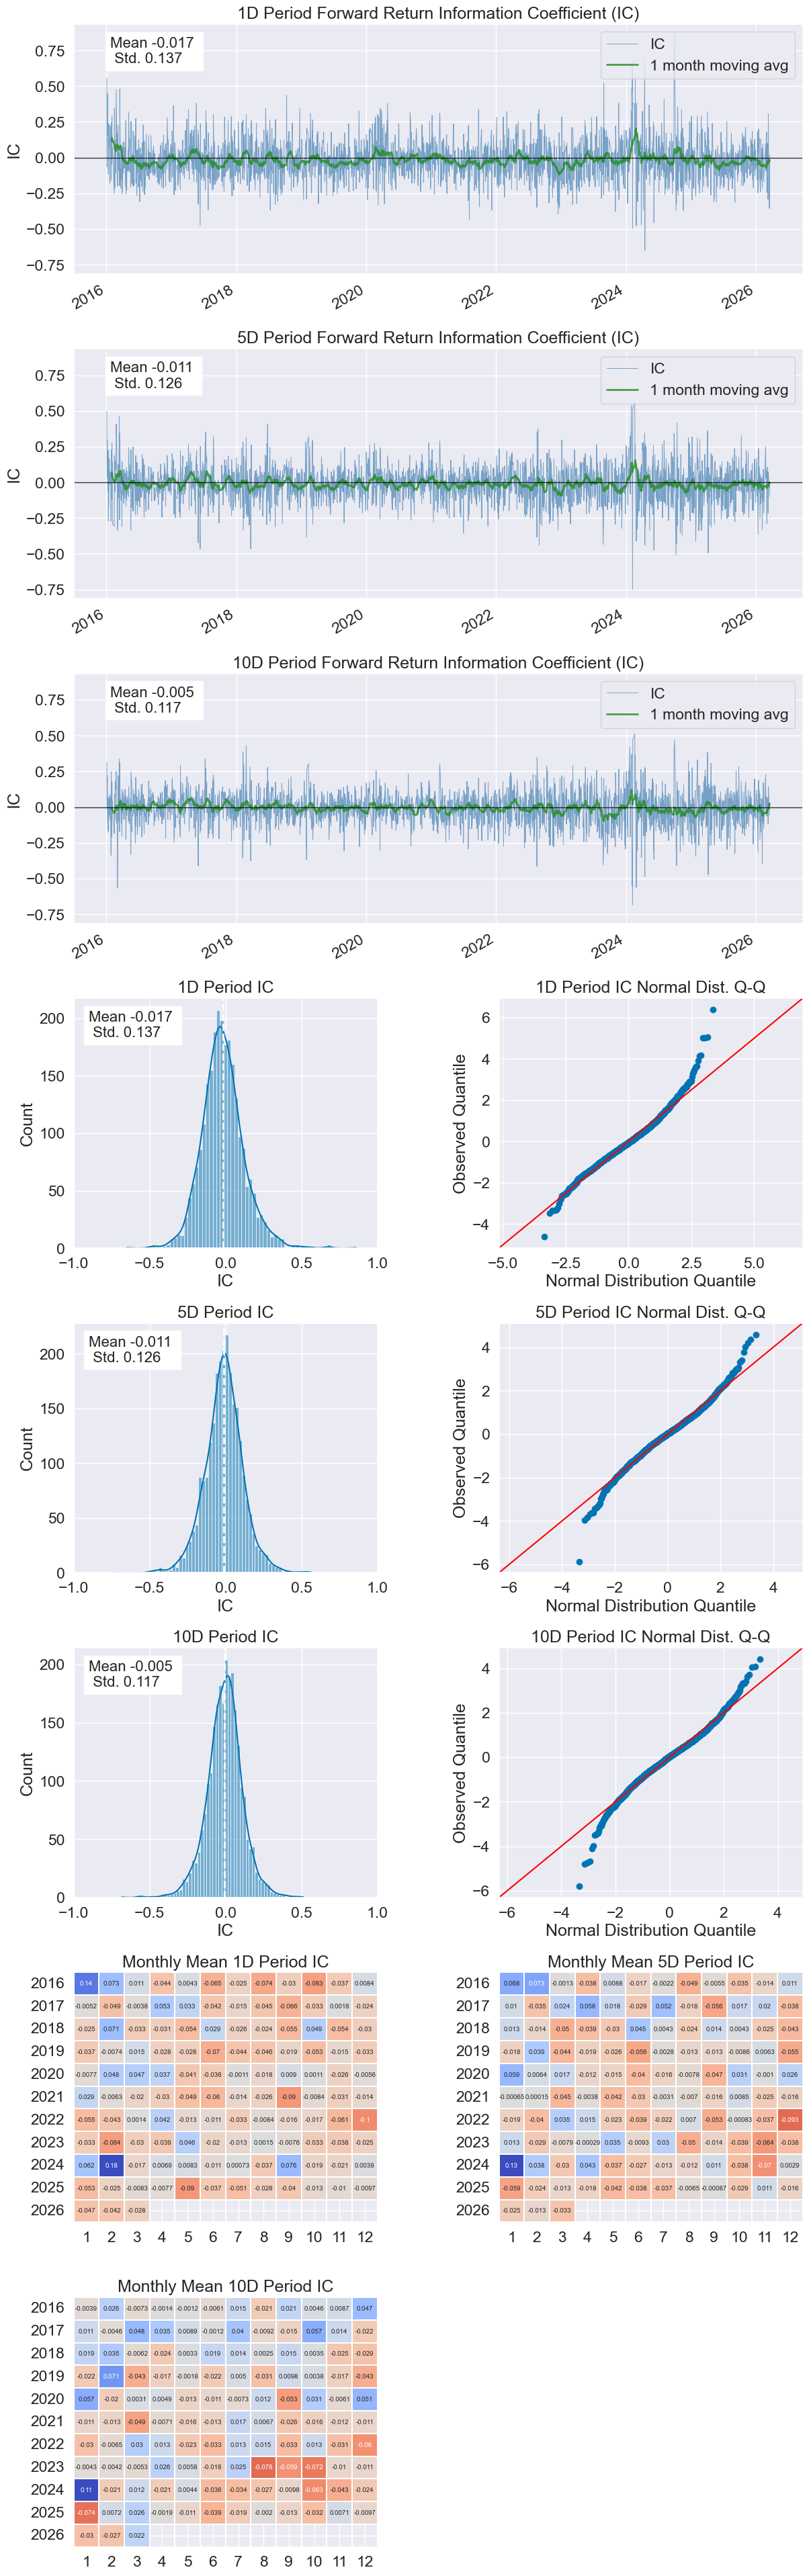

d:\Project\zer0factor\.venv\Lib\site-packages\alphalens\utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.759,0.770,0.771
Quantile 2 Mean Turnover,0.789,0.787,0.789
Quantile 3 Mean Turnover,0.753,0.767,0.771
Quantile 4 Mean Turnover,0.794,0.790,0.793
Quantile 5 Mean Turnover,0.749,0.774,0.777


,1D,5D,10D
Mean Factor Rank Autocorrelation,-0.017,-0.016,-0.005


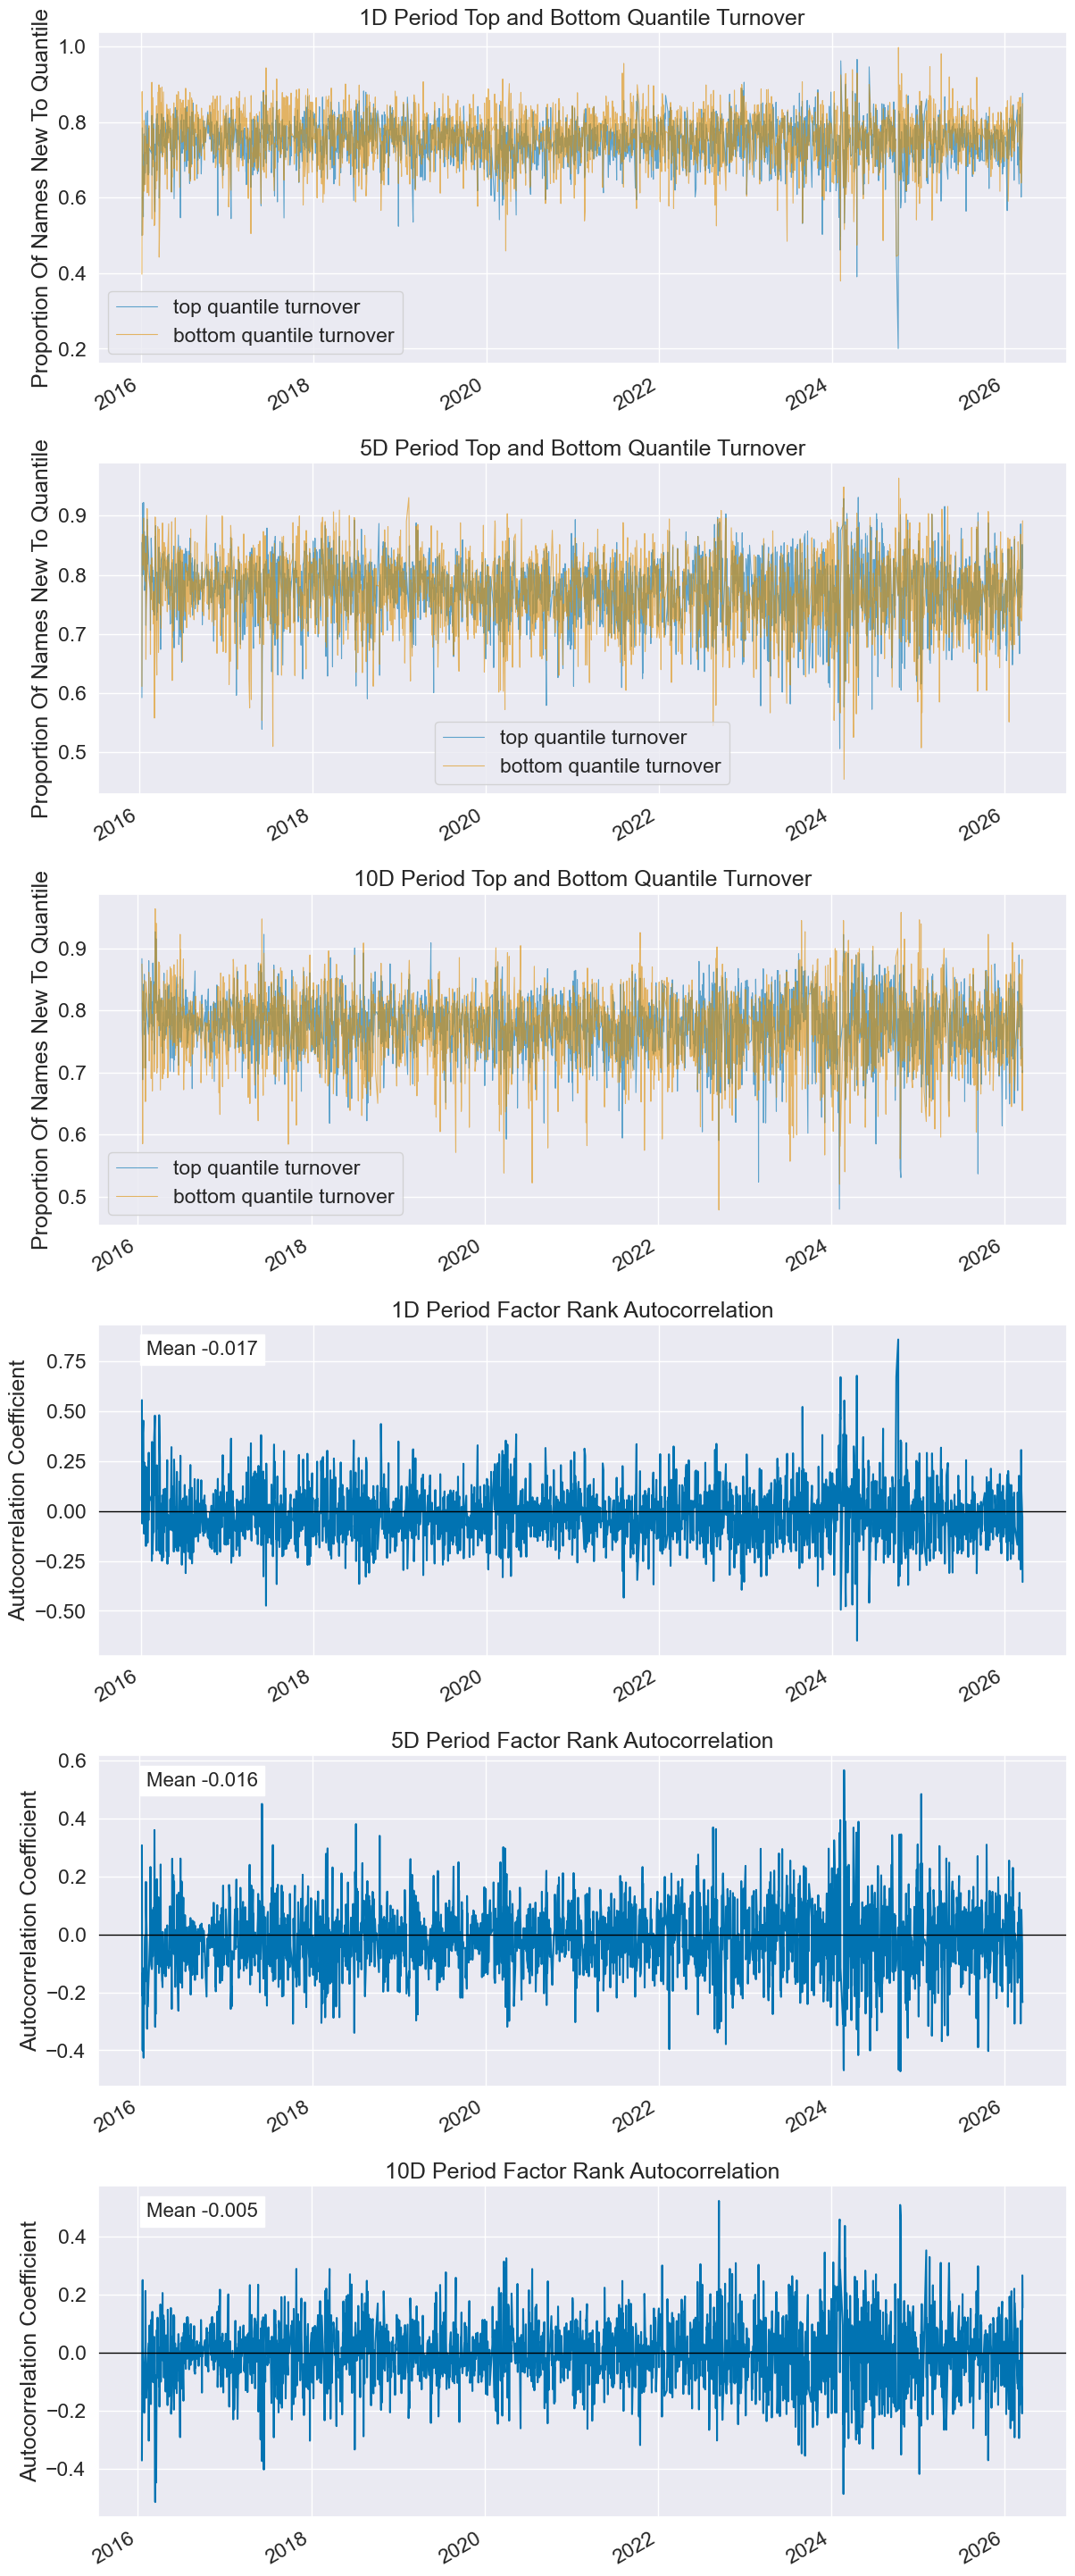

In [8]:
alphalens.tears.create_full_tear_sheet(factor_data, long_short=True)